# Praktyczne ćwiczenia z algorytmami optymalizacji dla uczenia maszynowego

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5417 - loss: 1.2603 - val_accuracy: 0.4000 - val_loss: 1.2620
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5417 - loss: 1.2463 - val_accuracy: 0.4333 - val_loss: 1.2484
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5500 - loss: 1.2327 - val_accuracy: 0.4333 - val_loss: 1.2348
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5667 - loss: 1.2192 - val_accuracy: 0.4667 - val_loss: 1.2219
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5750 - loss: 1.2058 - val_accuracy: 0.5000 - val_loss: 1.2092
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5833 - loss: 1.1932 - val_accuracy: 0.5333 - val_loss: 1.1969
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5833 - loss: 1.1802 - val_accuracy: 0.5333 - val_loss: 1.1847
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5833 - loss: 1.1677 - val_accuracy: 0.5333 - val_loss:

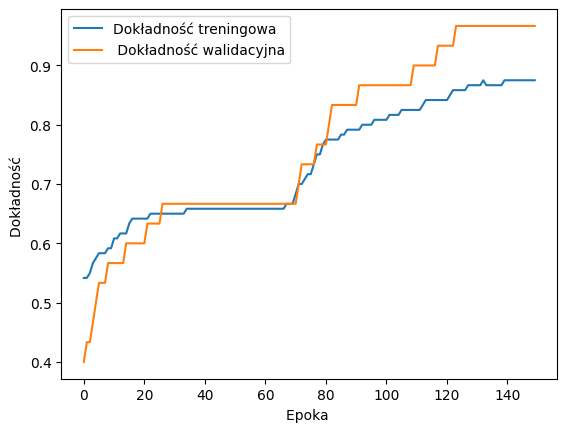

In [6]:
iris = load_iris ()
X, y = iris.data, iris.target
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model gęsty
model = tf.keras.Sequential([
        tf.keras.layers.Dense(10, activation='hard_sigmoid',input_shape=(4,)),
        tf.keras.layers.Dense(3, activation='softmax')
])

model.compile (optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=150, validation_data=(X_test , y_test))

# Ewaluacja
loss, acc = model.evaluate(X_test , y_test)
print ( f" Dokładność na zbiorze testowym: {acc :.2f}")

# Wykresy uczenia
plt.plot(history.history [ 'accuracy' ] , label= 'Dokładność treningowa' )
plt.plot(history.history [ 'val_accuracy' ] , label=' Dokładność walidacyjna' )
plt.xlabel ( 'Epoka ')
plt.ylabel ( 'Dokładność ')
plt.legend ()
plt.show()


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9487 - loss: 0.1671 - val_accuracy: 0.9789 - val_loss: 0.0691
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 25ms/step - accuracy: 0.9823 - loss: 0.0563 - val_accuracy: 0.9850 - val_loss: 0.0458
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9880 - loss: 0.0387 - val_accuracy: 0.9863 - val_loss: 0.0435
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9902 - loss: 0.0304 - val_accuracy: 0.9867 - val_loss: 0.0426
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9925 - loss: 0.0235 - val_accuracy: 0.9868 - val_loss: 0.0438
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9868 - loss: 0.0438
 Dokładność na zbiorze testowym: 0.99


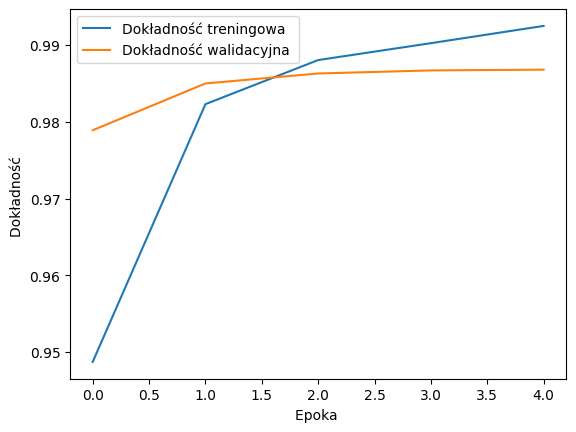

In [8]:
(x_train , y_train) , (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train [... , tf.newaxis]/255.0
x_test = x_test [... , tf.newaxis]/255.0

model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (2 ,2) , activation='relu' , input_shape=(28,28,1)),
        tf.keras.layers.MaxPooling2D((2 ,2)) ,
        tf.keras.layers.Conv2D(64, (2 ,2) , activation='relu') ,
        tf.keras.layers.MaxPooling2D((2 ,2)) ,
        tf.keras.layers.Flatten() ,
        tf.keras.layers.Dense(64, activation='relu') ,
        tf.keras.layers.Dense(10, activation='softmax')
        ])

model.compile (optimizer='adam' , loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model. fit (x_train , y_train , epochs=5, validation_data=(x_test , y_test))
# Ewaluacja
loss, acc = model.evaluate(x_test , y_test)
print( f" Dokładność na zbiorze testowym: {acc:.2f}")
# Wykresy uczenia
plt.plot(history.history ['accuracy'] , label='Dokładność treningowa' )
plt.plot(history.history ['val_accuracy' ], label='Dokładność walidacyjna ')
plt.xlabel ('Epoka ')
plt.ylabel ('Dokładność ')
plt.legend ()
plt.show()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 252s 319ms/step - accuracy: 0.7679 - loss: 0.4742 - val_accuracy: 0.7807 - val_loss: 0.4698
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 275s 351ms/step - accuracy: 0.8745 - loss: 0.3094 - val_accuracy: 0.8647 - val_loss: 0.3262
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 245s 314ms/step - accuracy: 0.9117 - loss: 0.2304 - val_accuracy: 0.8604 - val_loss: 0.3413
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 243s 311ms/step - accuracy: 0.9238 - loss: 0.2086 - val_accuracy: 0.8678 - val_loss: 0.3326
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 246s 314ms/step - accuracy: 0.9242 - loss: 0.1962 - val_accuracy: 0.8307 - val_loss: 0.4379
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.8307 - loss: 0.4379
 Dokładność na zbiorze testowym: 0.83


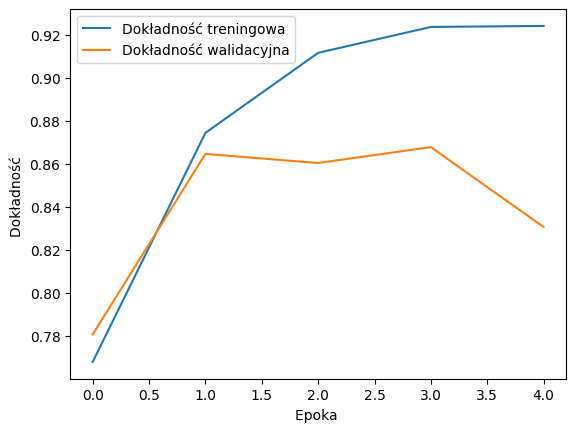

In [3]:
(x_train , y_train), (x_test , y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train , maxlen=500)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test , maxlen=500)
model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=10000, output_dim=32),
        tf.keras.layers.LSTM(64) ,
        tf.keras.layers.Dense(1 , activation='sigmoid')
])
model.compile(optimizer='adam' , loss='binary_crossentropy', metrics=[ 'accuracy'])
history = model.fit (x_train , y_train , epochs=5, validation_data=(x_test , y_test))
# Ewaluacja
loss, acc = model.evaluate(x_test , y_test)
print( f" Dokładność na zbiorze testowym: {acc:.2f}")
# Wykresy uczenia
plt.plot(history.history ['accuracy'] , label='Dokładność treningowa' )
plt.plot(history.history ['val_accuracy' ], label='Dokładność walidacyjna')
plt.xlabel ('Epoka ')
plt.ylabel ('Dokładność ')
plt.legend ()
plt.show()

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 559s 1s/step - accuracy: 0.6485 - loss: 0.6008 - val_accuracy: 0.7840 - val_loss: 0.4552
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 530s 1s/step - accuracy: 0.8832 - loss: 0.2858 - val_accuracy: 0.8716 - val_loss: 0.3031
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 566s 1s/step - accuracy: 0.9195 - loss: 0.2088 - val_accuracy: 0.8718 - val_loss: 0.3114
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 551s 1s/step - accuracy: 0.9403 - loss: 0.1643 - val_accuracy: 0.8764 - val_loss: 0.3089
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.9535 - loss: 0.1301 - val_accuracy: 0.8773 - val_loss: 0.3032
782/782 ━━━━━━━━━━━━━━━━━━━━ 130s 166ms/step - accuracy: 0.8773 - loss: 0.3032

Dokładność na zbiorze testowym: 0.88


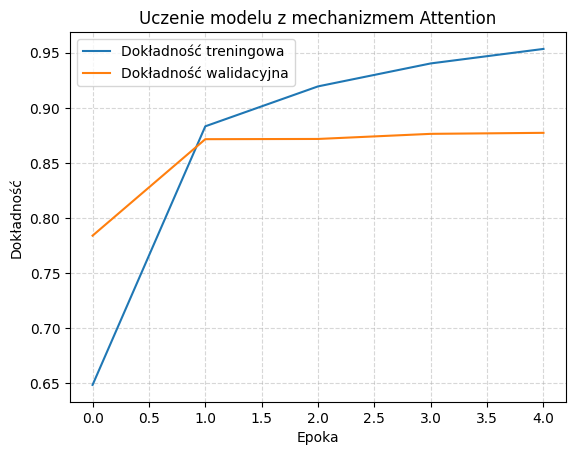

In [12]:

num_words = 10000
maxlen = 500
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=num_words)

x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

inputs = tf.keras.Input(shape=(maxlen,))
embedding = tf.keras.layers.Embedding(input_dim=num_words, output_dim=32)(inputs)
lstm_out = tf.keras.layers.LSTM(64, return_sequences=True)(embedding)
attention_out = tf.keras.layers.Attention()([lstm_out, lstm_out])
pooled_out = tf.keras.layers.GlobalAveragePooling1D()(attention_out)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(pooled_out)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#model.summary()
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

loss, acc = model.evaluate(x_test, y_test)
print(f"\nDokładność na zbiorze testowym: {acc:.2f}")

plt.plot(history.history['accuracy'], label='Dokładność treningowa')
plt.plot(history.history['val_accuracy'], label='Dokładność walidacyjna')
plt.title('Uczenie modelu z mechanizmem Attention')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Trenowanie modelu z inicjalizacją: Glorot (Xavier) Uniform...

Trenowanie modelu z inicjalizacją: He Normal...

Trenowanie modelu z inicjalizacją: Random Normal...


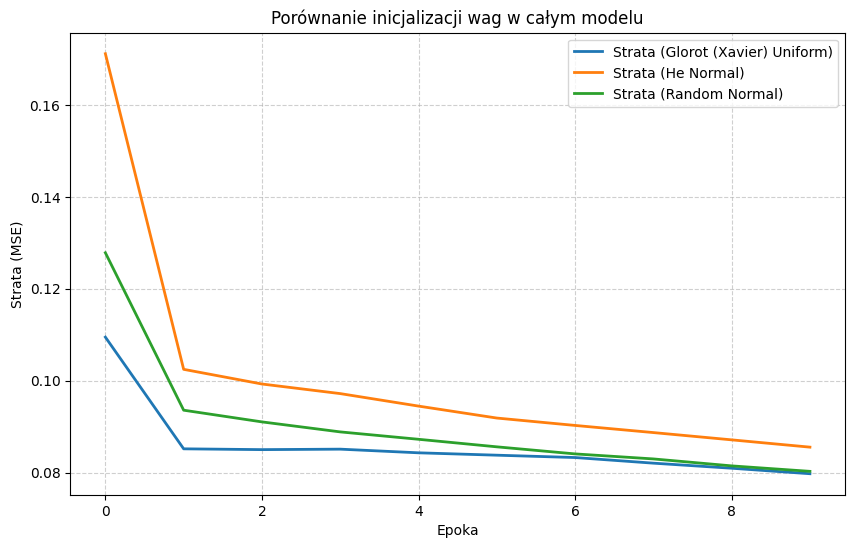

In [11]:

# 1. Przygotowanie sztucznych danych sekwencyjnych
X = np.random.rand(1000, 10, 512)
Y = np.random.rand(1000, 512)

# Słownik na wyniki
histories = {}

# Słownik z obiektami inicjalizatorów – przekazujemy je uniwersalnie
initializers = {
    'Glorot (Xavier) Uniform': tf.keras.initializers.GlorotUniform(),
    'He Normal': tf.keras.initializers.HeNormal(),
    'Random Normal': tf.keras.initializers.RandomNormal()
}

# 2. Pętla uruchamiająca eksperymenty (teraz modyfikuje OBIE warstwy)
for name, init in initializers.items():
    print(f"\nTrenowanie modelu z inicjalizacją: {name}...")

    input_layer = tf.keras.layers.Input(shape=(10, 512))

    # Zmiana 1: Inicjalizator dodany do MultiHeadAttention
    attention_output = tf.keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=64,
        kernel_initializer=init,
        bias_initializer='zeros'
    )(input_layer, input_layer)

    attention_output = tf.keras.layers.GlobalAveragePooling1D()(attention_output)

    # Zmiana 2: Ten sam inicjalizator dodany do Dense
    output = tf.keras.layers.Dense(
        512,
        activation='linear',
        kernel_initializer=init,
        bias_initializer='zeros'
    )(attention_output)

    model = tf.keras.Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='mse')

    # Trening
    history = model.fit(X, Y, epochs=10, batch_size=32, verbose=0)
    histories[name] = history.history['loss']

# 3. Wykres porównawczy
plt.figure(figsize=(10, 6))
for name, loss_values in histories.items():
    plt.plot(loss_values, label=f'Strata ({name})', linewidth=2)

plt.title('Porównanie inicjalizacji wag w całym modelu')
plt.xlabel('Epoka')
plt.ylabel('Strata (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()